In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

raw_dir = Path("../data/raw")
processed_dir = Path("../data/processed")
processed_dir.mkdir(exist_ok=True)

In [2]:
def grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def denoise(gray):
    return cv2.fastNlMeansDenoising(gray, h=10)

def upscale(gray, scale=2):
    h, w = gray.shape
    if w < 1000:
        return cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    return gray

def adaptive_threshold(gray):
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 10
    )

def deskew(binary):
    # Use BLACK pixels (text), not white (background)
    coords = np.column_stack(np.where(binary == 0))
    if len(coords) < 10:
        return binary
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    # Only correct if tilt is meaningful
    if abs(angle) < 0.5:
        return binary
    h, w = binary.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(binary, M, (w, h),
                             flags=cv2.INTER_NEAREST,
                             borderMode=cv2.BORDER_REPLICATE)
    return rotated

def preprocess(img):
    gray    = grayscale(img)
    gray    = denoise(gray)
    gray    = upscale(gray)          # upscale on grayscale FIRST
    binary  = adaptive_threshold(gray)
    result  = deskew(binary)         # deskew on binary AFTER
    return result

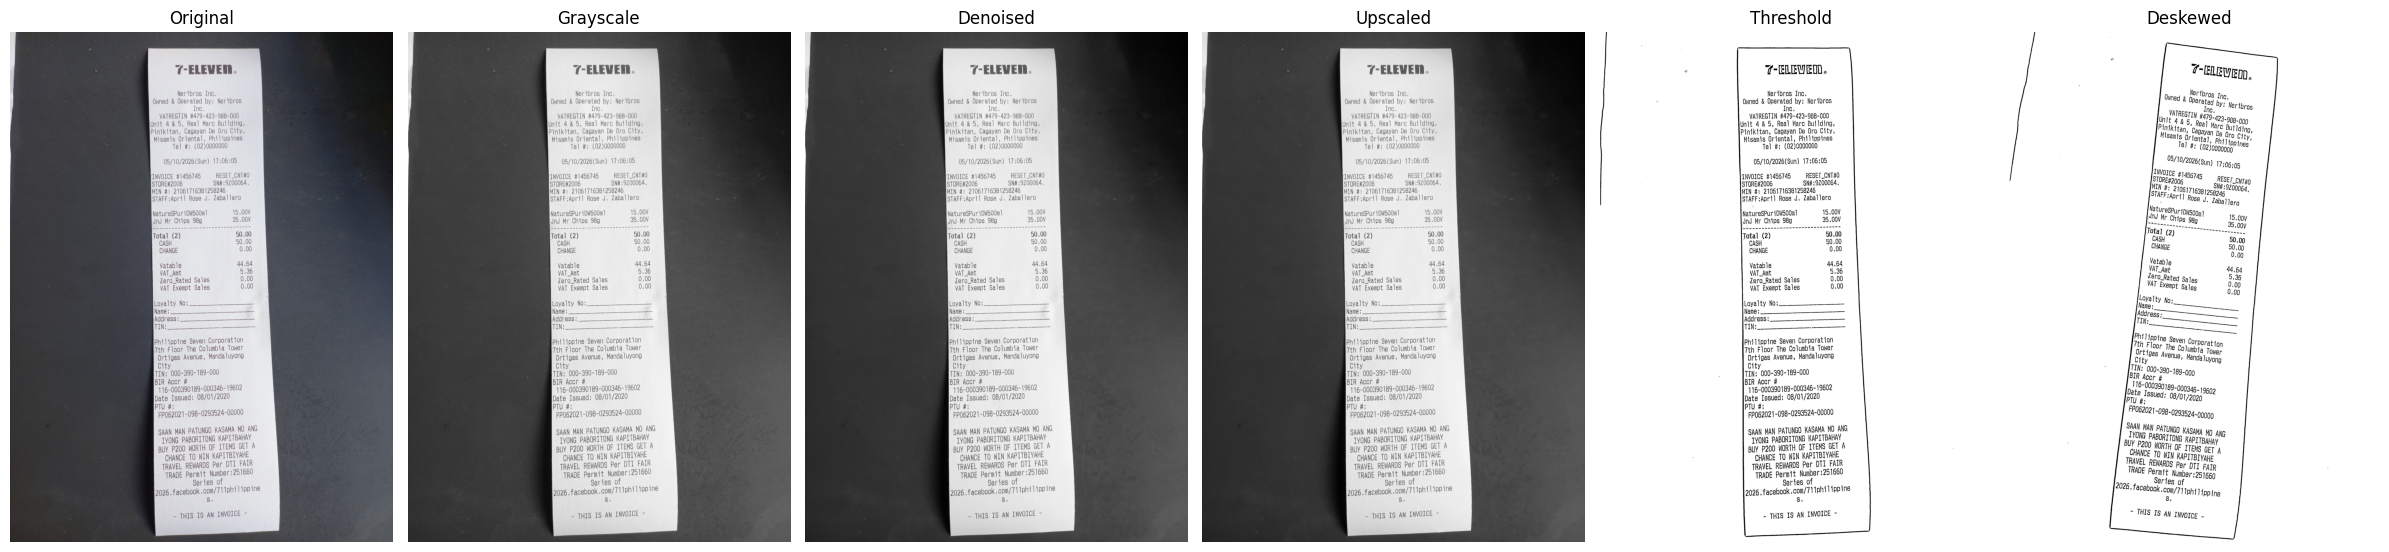

In [3]:
sample = cv2.imread(str(raw_dir / "receipt_01.jpg"))

gray    = grayscale(sample)
denoised = denoise(gray)
upscaled = upscale(denoised)
binary  = adaptive_threshold(upscaled)
final   = deskew(binary)

titles = ["Original", "Grayscale", "Denoised", "Upscaled", "Threshold", "Deskewed"]
images = [cv2.cvtColor(sample, cv2.COLOR_BGR2RGB), gray, denoised, upscaled, binary, final]
cmaps  = [None, "gray", "gray", "gray", "gray", "gray"]

fig, axes = plt.subplots(1, 6, figsize=(24, 6))
for ax, img, title, cmap in zip(axes, images, titles, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/preprocessing_comparison.png")
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv("../data/annotated/ground_truth.csv")

for _, row in df.iterrows():
    img = cv2.imread(str(raw_dir / row["filename"]))
    if img is None:
        print(f"Could not read {row['filename']}")
        continue

    final = preprocess(img)

    out_path = processed_dir / row["filename"]
    cv2.imwrite(str(out_path), final)
    print(f"Saved: {out_path}")

print("All receipts preprocessed.")

Saved: ..\data\processed\receipt_01.jpg
Saved: ..\data\processed\receipt_02.jpg
Saved: ..\data\processed\receipt_03.jpg
Saved: ..\data\processed\receipt_04.jpg
Saved: ..\data\processed\receipt_05.jpg
Saved: ..\data\processed\receipt_06.jpg
Saved: ..\data\processed\receipt_07.jpg
Saved: ..\data\processed\receipt_08.jpg
Saved: ..\data\processed\receipt_09.jpg
Saved: ..\data\processed\receipt_10.jpg
Saved: ..\data\processed\receipt_11.jpg
Saved: ..\data\processed\receipt_12.jpg
Saved: ..\data\processed\receipt_13.jpg
Saved: ..\data\processed\receipt_14.jpg
Saved: ..\data\processed\receipt_15.jpg
Saved: ..\data\processed\receipt_16.jpg
Saved: ..\data\processed\receipt_17.jpg
All receipts preprocessed.
